In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/abalone.csv")
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [53]:
df=df.drop("id", axis =1)
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [54]:
df.loc[df['Height'] == 0, 'Height'] = df['Height'].median() # 0값 대체
df = df[df['Height'] < 0.4] # 이상치 제거

In [55]:
#파생변수
df['Volume'] = df['Length'] * df['Diameter'] * df['Height'] # 부피 추정
df['Meat_Yield'] = df['Shucked_weight'] / df['Whole_weight'] # 무게 비율

In [56]:
#원핫인코딩
df = pd.get_dummies(df, columns=['Sex'], prefix='Sex')

In [57]:
selected_features = [
    'Length', 'Diameter', 'Height',
    'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight',
    'Volume', 'Meat_Yield',
    'Sex_F', 'Sex_I', 'Sex_M'
]
X = df[selected_features].values
X

array([[0.455, 0.365, 0.095, ..., False, False, True],
       [0.35, 0.265, 0.09, ..., False, False, True],
       [0.53, 0.42, 0.135, ..., True, False, False],
       ...,
       [0.6, 0.475, 0.205, ..., False, False, True],
       [0.625, 0.485, 0.15, ..., True, False, False],
       [0.71, 0.555, 0.195, ..., False, False, True]], dtype=object)

In [58]:
y = df['Rings']
y

,Rings
0,15
1,7
2,9
3,10
4,7
...,...
4172,11
4173,10
4174,9
4175,10


In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)



In [60]:
#스케일링
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

In [61]:
#Defining the model

from keras.models import Sequential
from keras.optimizers import SGD,Adam
from keras.layers import Dense, Input, Dropout

model = Sequential()

model = Sequential([
    Input(shape=(12,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer = 'adam', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 5,057 (19.75 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape,

((3340, 12), (3340,), (835, 12), (835,))

In [63]:
N_EPOCHS = 100 #10->100

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6322 - mse: 0.6322 - val_loss: 0.4875 - val_mse: 0.4875
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.4963 - mse: 0.4963 - val_loss: 0.4466 - val_mse: 0.4466
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4764 - mse: 0.4764 - val_loss: 0.4515 - val_mse: 0.4515
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4615 - mse: 0.4615 - val_loss: 0.4125 - val_mse: 0.4125
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4519 - mse: 0.4519 - val_loss: 0.4236 - val_mse: 0.4236
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4427 - mse: 0.4427 - val_loss: 0.4194 - val_mse: 0.4194
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4531 - mse: 0.4531 - val_loss: 0.4366 - val_mse: 0.4366
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4463 - mse: 0.4463 - val_loss: 0.4255 - val_mse: 0.4255
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8

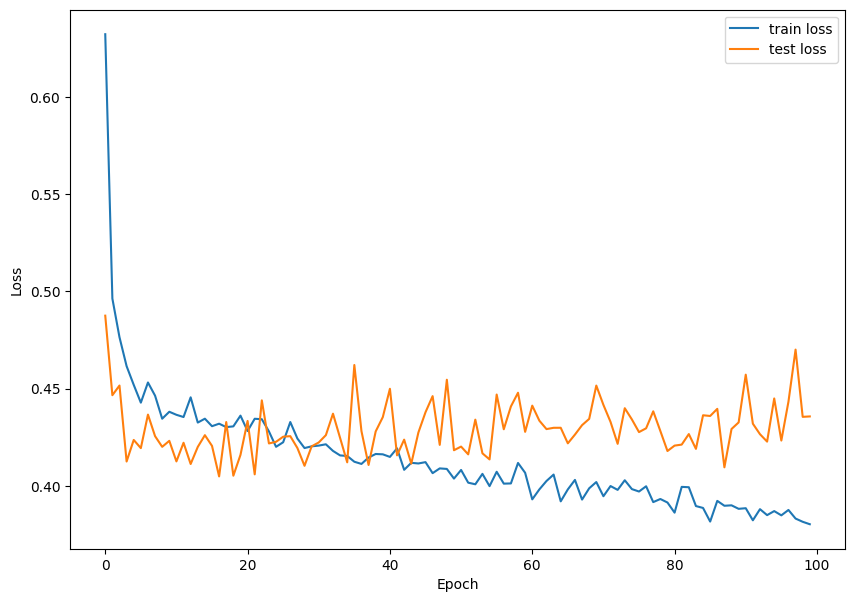

In [64]:
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [65]:
model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4356 - mse: 0.4356 


[0.4356485605239868, 0.4356485605239868]

In [66]:
y_pred_s = y_pred.flatten()

In [67]:
y_pred_orig = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

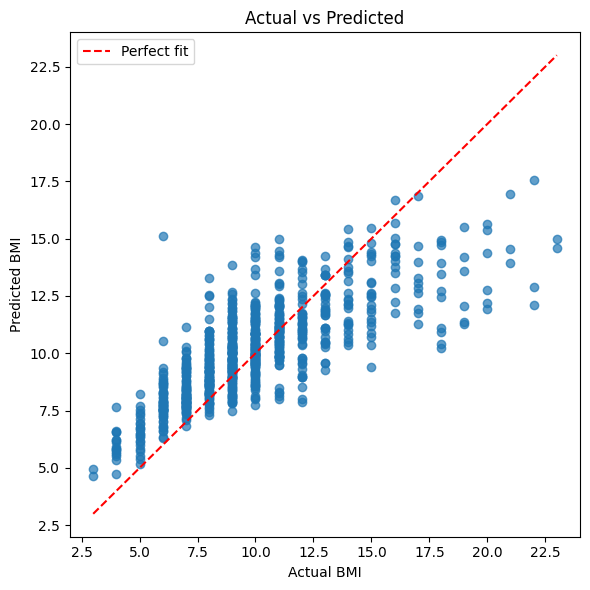

In [68]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.7)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'r--', label='Perfect fit')
plt.xlabel('Actual BMI')
plt.ylabel('Predicted BMI')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()